/tmp/ipykernel_1458896/2695042671.py:27: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(handle)


(128, 128, 128)
used time: 42.409563302993774 s


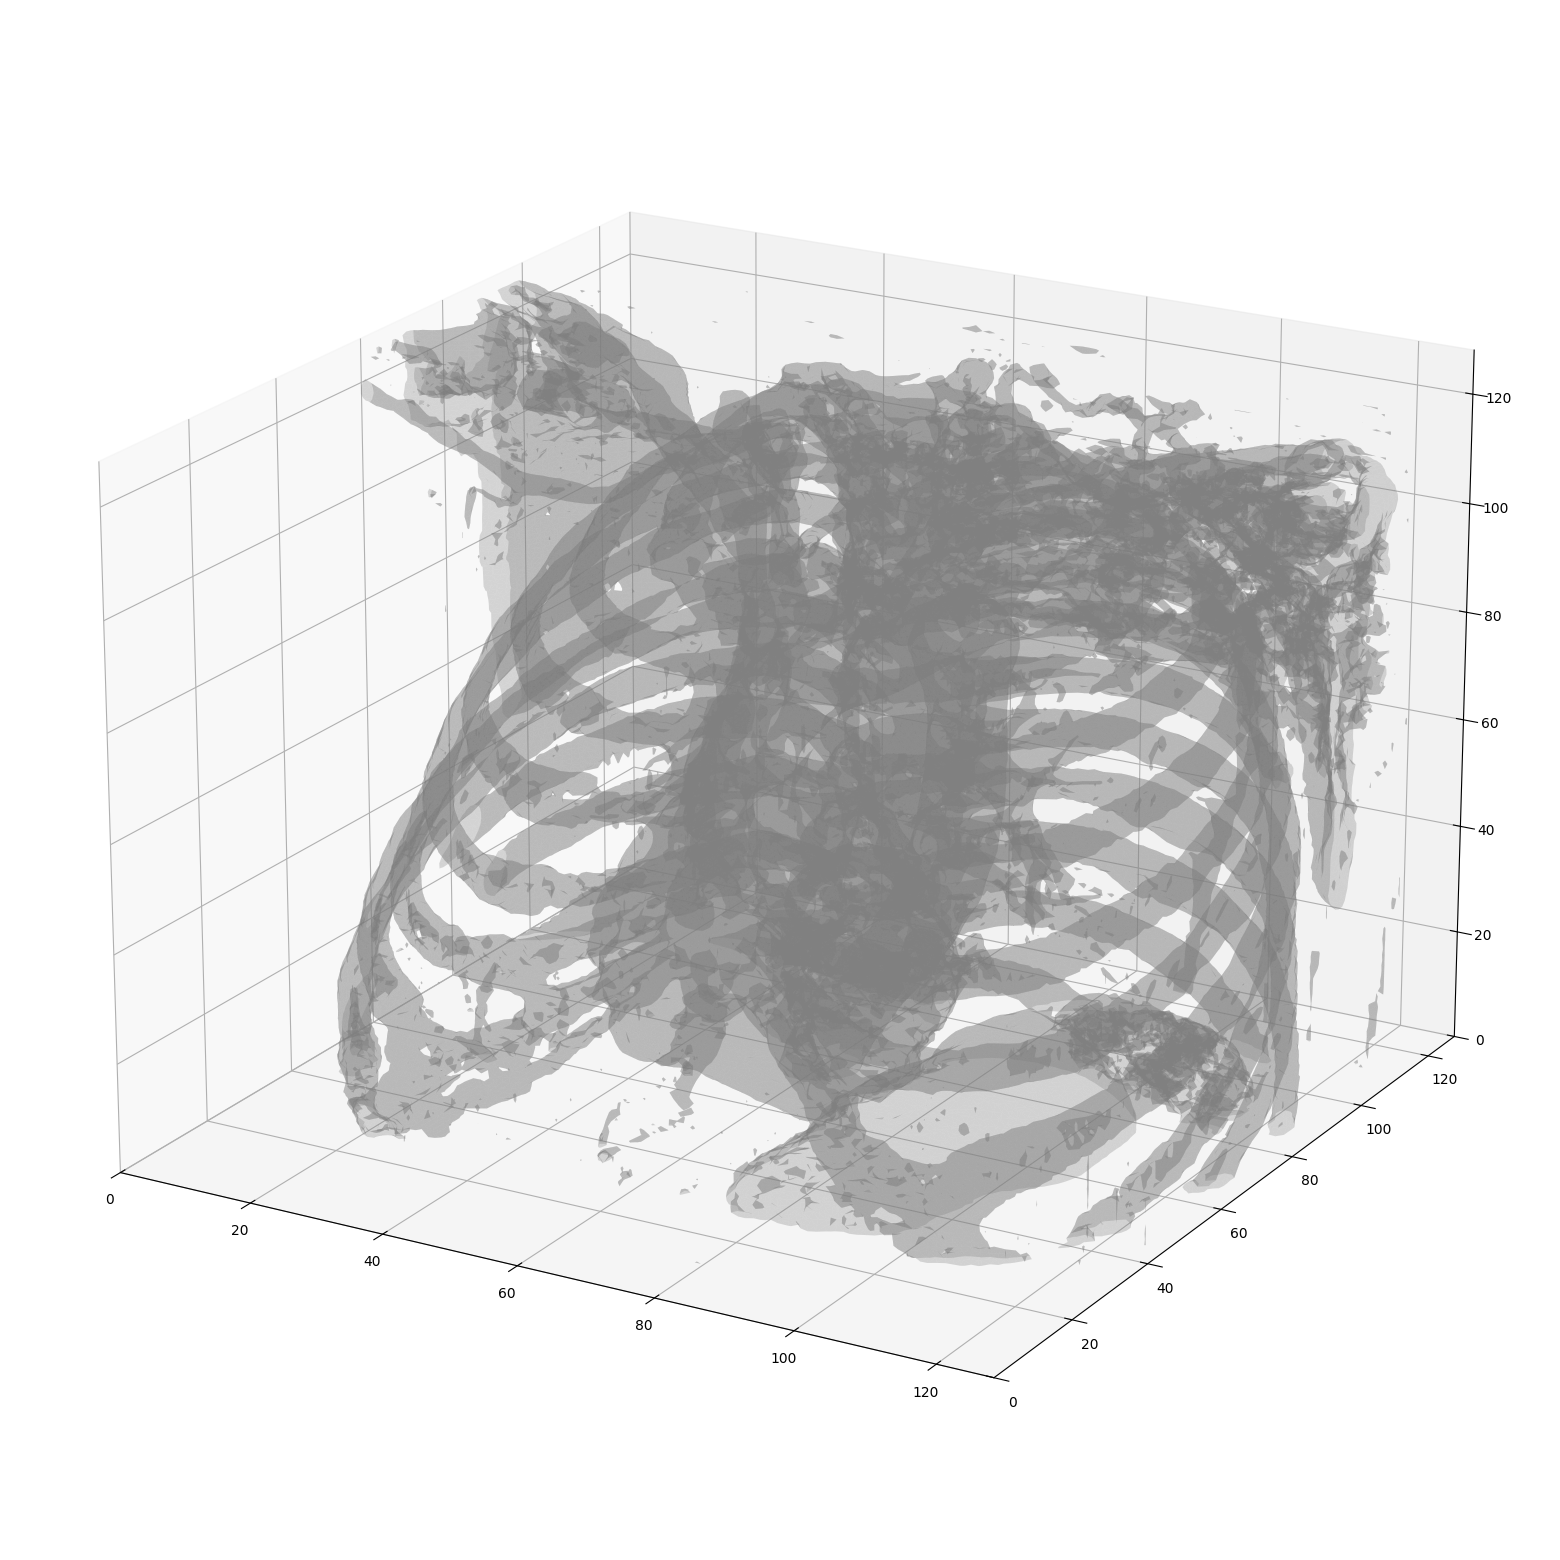

In [2]:
# export LD_LIBRARY_PATH=/home/ycai51/anaconda3/envs/naf/lib
import os
import os.path as osp
from tqdm import tqdm
import numpy as np
from skimage import measure
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import time
import pickle

# from src.dataset import TIGREDataset as Dataset

from pdb import set_trace as stx
import argparse

start = time.time()

# os.environ["CUDA_DEVICE_ORDER"] = 'PCI_BUS_ID'

category = 'chest'
save_dir = category + '/'

path = f'data/{category}_50.pickle'

with open(path, "rb") as handle:
            data = pickle.load(handle)

'''
    采用 np.rot90 和 np.flip 实现旋转和翻转

    B0 = np.rot90(A, 1, (0,1)) #绕 z 轴旋转90度
    B1 = np.rot90(A,-1, (0,1)) #绕 z 轴旋转270度
    B2 = np.rot90(A, 1, (1,2)) #绕 x 轴旋转90度
    B3 = np.rot90(A,-1, (1,2)) #绕 x 轴旋转270度
    B4 = np.rot90(A, 1, (0,2)) #绕 y 轴旋转90度
    B5 = np.rot90(A,-1, (0,2)) #绕 y 轴旋转270度

    B6 = np.flip(A, 2) #z轴翻折
    B7 = np.flip(A, 1) #y轴翻折
    B8 = np.flip(A, 0) #x轴翻折
'''

CT_image = data["image"]
# CT_image = CT_image[...,::-1]
# CT_image = CT_image[...,::-1]
CT_image = CT_image[::-1,...]
CT_image = np.rot90(CT_image, -1, (0,1))

print(CT_image.shape)

# stx()

min_value = CT_image.min()
max_value = CT_image.max()
sigma = 0.55
threshold = sigma * min_value + (1 - sigma) * max_value
verts, faces, _, _ = measure.marching_cubes(CT_image, threshold)

# stx()

fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')

# Fancy indexing: `verts[faces]` to generate a collection of triangles
alpha = 0.30
mesh = Poly3DCollection(verts[faces], alpha=alpha)
face_color = [0.5, 0.5, 0.5]
mesh.set_facecolor(face_color)
ax.add_collection3d(mesh)

ax.set_xlim(0, CT_image.shape[0])
ax.set_ylim(0, CT_image.shape[1])
ax.set_zlim(0, CT_image.shape[2])

alpha_axis = 0.01
ax.set_alpha(alpha_axis)

elevation = 20
ax.view_init(elev=elevation)

# plt.savefig(f'3d_chest_{alpha}.png')
os.makedirs(save_dir, exist_ok=True)
plt.savefig(f'{save_dir}3d_{category}_{sigma}_{alpha}_{alpha_axis}.png')

print(f"used time: {time.time()-start} s")

In [3]:
import pickle

path = "data/chest_50.pickle"
with open(path, "rb") as f:
    data = pickle.load(f)

print(type(data))
if isinstance(data, dict):
    print(data.keys())
    for k, v in data.items():
        try:
            print(k, type(v), getattr(v, "shape", None))
        except Exception:
            print(k, type(v))

<class 'dict'>
dict_keys(['numTrain', 'numVal', 'DSD', 'DSO', 'nDetector', 'dDetector', 'nVoxel', 'dVoxel', 'offOrigin', 'offDetector', 'accuracy', 'mode', 'filter', 'totalAngle', 'startAngle', 'randomAngle', 'convert', 'rescale_slope', 'rescale_intercept', 'normalize', 'noise', 'image', 'train', 'val'])
numTrain <class 'int'> None
numVal <class 'int'> None
DSD <class 'float'> None
DSO <class 'float'> None
nDetector <class 'list'> None
dDetector <class 'list'> None
nVoxel <class 'list'> None
dVoxel <class 'list'> None
offOrigin <class 'list'> None
offDetector <class 'list'> None
accuracy <class 'float'> None
mode <class 'str'> None
filter <class 'NoneType'> None
totalAngle <class 'float'> None
startAngle <class 'float'> None
randomAngle <class 'bool'> None
convert <class 'bool'> None
rescale_slope <class 'float'> None
rescale_intercept <class 'float'> None
normalize <class 'bool'> None
noise <class 'int'> None
image <class 'numpy.ndarray'> (128, 128, 128)
train <class 'dict'> None
val 

/tmp/ipykernel_1458896/1327804936.py:5: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(f)


/tmp/ipykernel_1458896/2645060279.py:10: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(f)


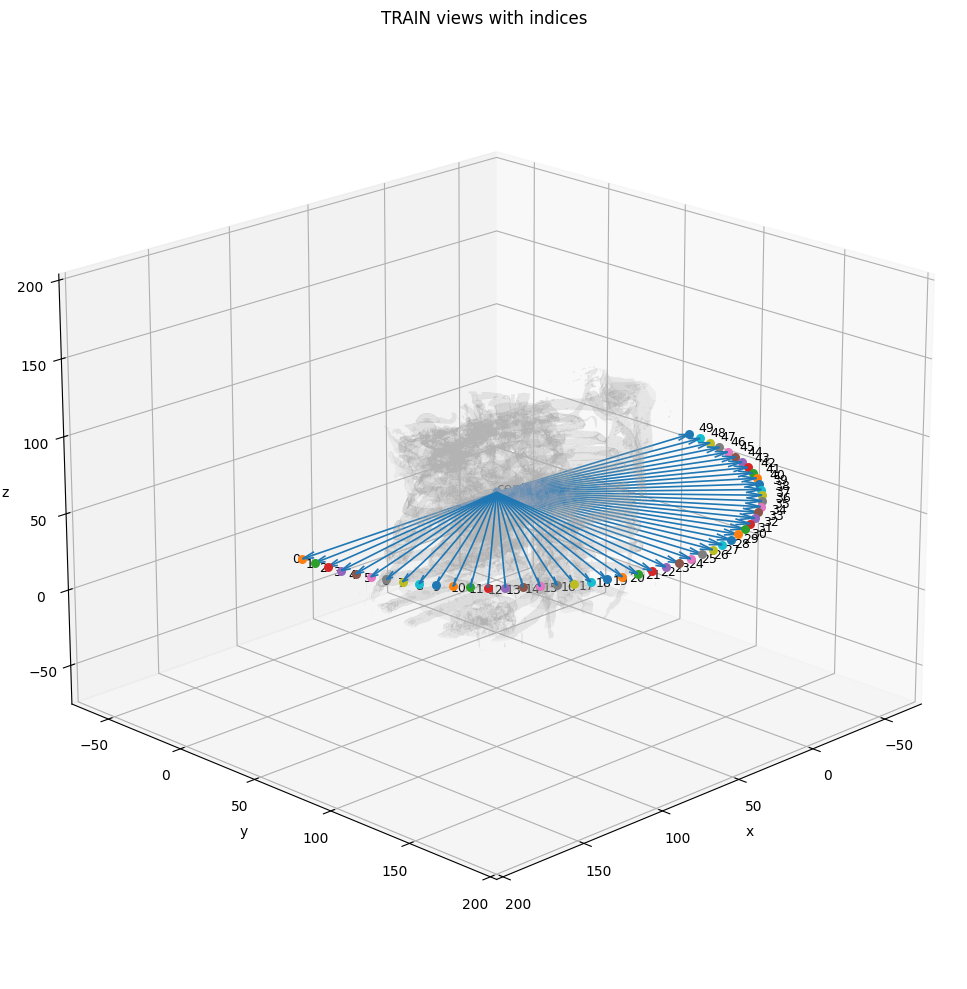

In [13]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

PICKLE_PATH = "data/chest_50.pickle"

with open(PICKLE_PATH, "rb") as f:
    data = pickle.load(f)

# ---------------------------------------------------
# Load and orient the volume similarly to your script
# ---------------------------------------------------
volume = np.asarray(data["image"])
volume = volume[::-1, ...]
volume = np.rot90(volume, -1, (0, 1))

# ---------------------------------------------------
# Build a 3D surface mesh
# ---------------------------------------------------
sigma = 0.55
min_value = float(volume.min())
max_value = float(volume.max())
threshold = sigma * min_value + (1 - sigma) * max_value

verts, faces, _, _ = measure.marching_cubes(volume, threshold)

# Center of the volume
cx = volume.shape[0] / 2.0
cy = volume.shape[1] / 2.0
cz = volume.shape[2] / 2.0

# Radius for view markers outside the object
# radius = 0.75 * max(volume.shape)
radius = 0.95 * max(volume.shape)

def plot_split_views(split_name: str, elev: float = 20, azim: float = 45):
    angles = np.asarray(data[split_name]["angles"], dtype=float)

    fig = plt.figure(figsize=(11, 10))
    ax = fig.add_subplot(111, projection="3d")

    # -----------------------------
    # Draw CT surface
    # -----------------------------
    mesh = Poly3DCollection(verts[faces], alpha=0.12)
    mesh.set_facecolor([0.7, 0.7, 0.7])
    ax.add_collection3d(mesh)

    # -----------------------------
    # Draw center
    # -----------------------------
    ax.scatter([cx], [cy], [cz], s=40)
    ax.text(cx, cy, cz, "center", fontsize=10)

    # -----------------------------
    # Draw view directions
    # -----------------------------
    for i, theta in enumerate(angles):
        # point on a circle around the object in the x-y plane
        x = cx + radius * np.cos(theta)
        y = cy + radius * np.sin(theta)
        z = cz

        # dot for view position
        ax.scatter([x], [y], [z], s=30)

        # arrow from center to view
        dx = x - cx
        dy = y - cy
        dz = z - cz
        ax.quiver(
            cx, cy, cz,
            dx, dy, dz,
            arrow_length_ratio=0.06,
            linewidth=1.2,
            normalize=False
        )

        # number label for projection index
        label_scale = 1.05
        lx = cx + label_scale * dx
        ly = cy + label_scale * dy
        lz = cz + label_scale * dz
        ax.text(lx, ly, lz, str(i), fontsize=9)

    # -----------------------------
    # Axes / view
    # -----------------------------
    pad = radius * 1.15
    ax.set_xlim(cx - pad, cx + pad)
    ax.set_ylim(cy - pad, cy + pad)
    ax.set_zlim(cz - pad, cz + pad)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title(f"{split_name.upper()} views with indices")

    ax.view_init(elev=elev, azim=azim)
    plt.tight_layout()
    plt.show()

# Make one plot for training and one for validation
plot_split_views("train")
# plot_split_views("val")

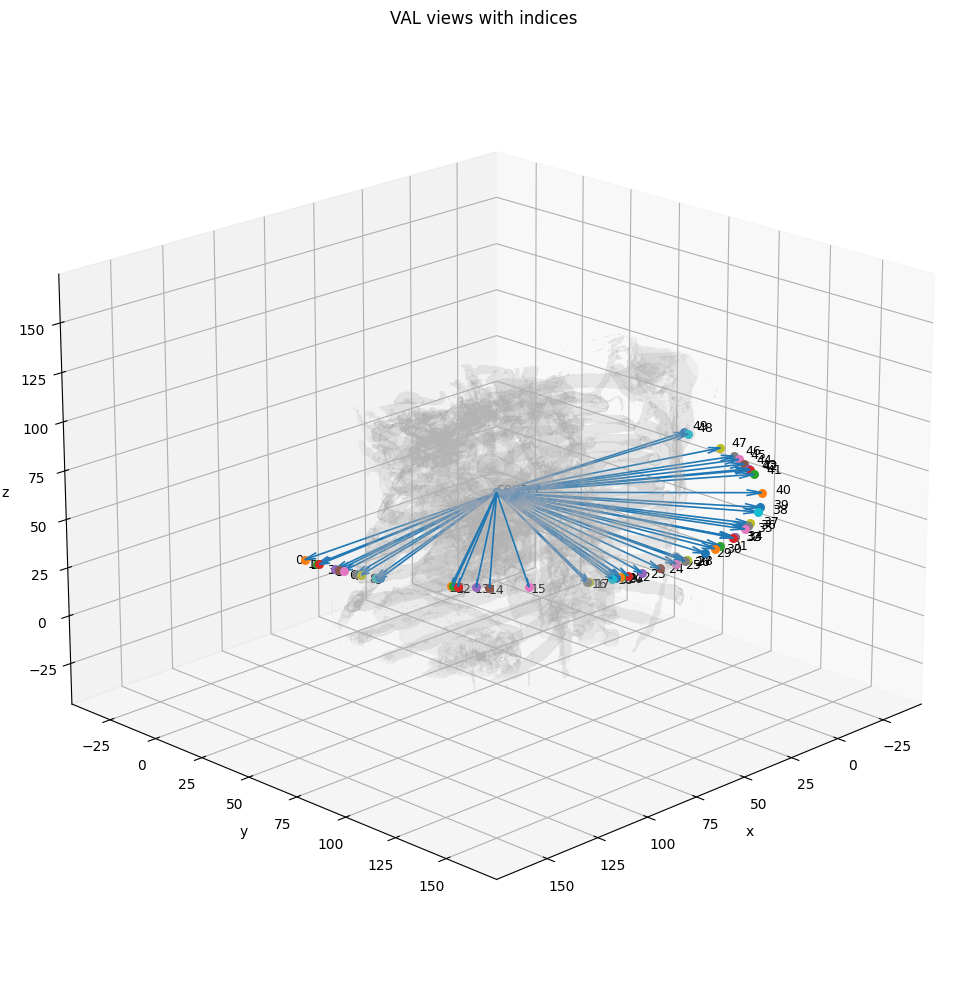

In [8]:
plot_split_views("val")

/tmp/ipykernel_2478241/3454591712.py:10: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(f)


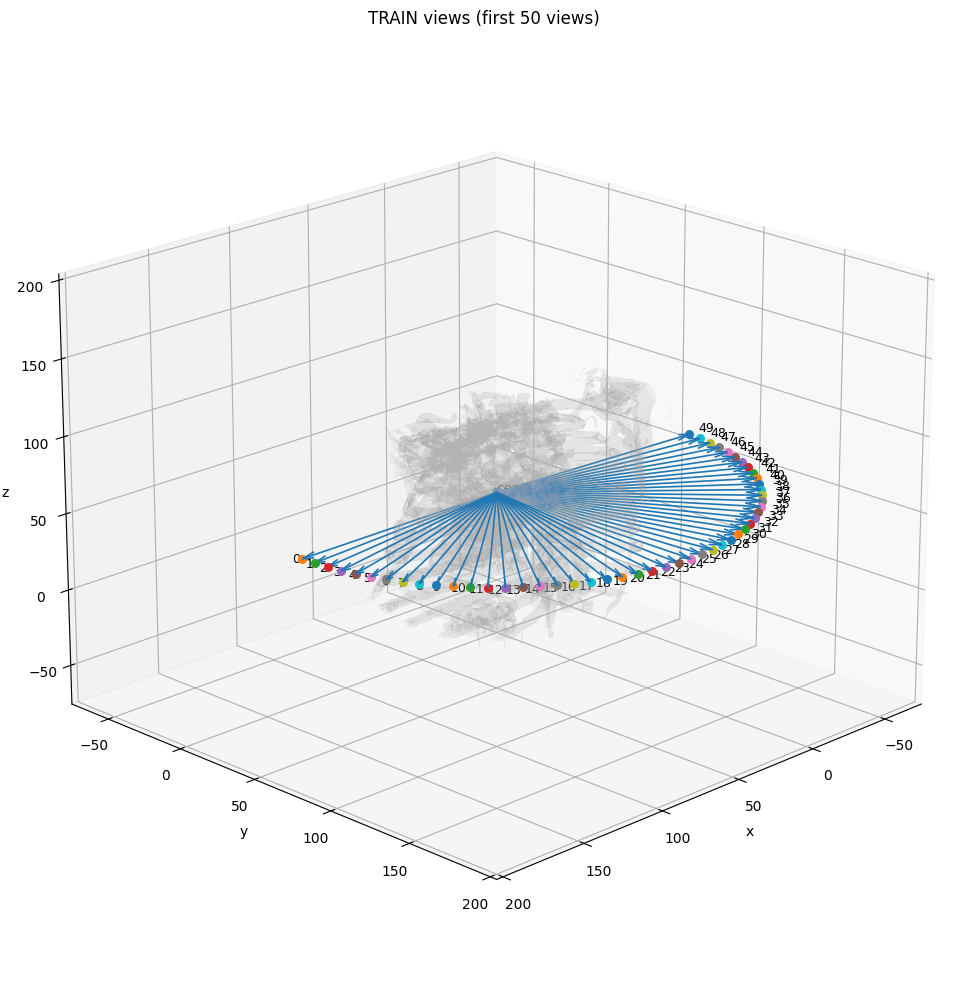

In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

PICKLE_PATH = "data/chest_50.pickle"

with open(PICKLE_PATH, "rb") as f:
    data = pickle.load(f)

# ---------------------------------------------------
# Load the FULL volume
# Do NOT slice the volume based on number of views
# ---------------------------------------------------
volume = np.asarray(data["image"])
volume = volume[::-1, ...]
volume = np.rot90(volume, -1, (0, 1))

# ---------------------------------------------------
# Build a 3D surface mesh from the full volume
# ---------------------------------------------------
sigma = 0.55
min_value = float(volume.min())
max_value = float(volume.max())
threshold = sigma * min_value + (1 - sigma) * max_value

verts, faces, _, _ = measure.marching_cubes(volume, threshold)

# Center of the volume
cx = volume.shape[0] / 2.0
cy = volume.shape[1] / 2.0
cz = volume.shape[2] / 2.0

# Radius for view markers outside the object
radius = 0.95 * max(volume.shape)


def get_selected_views(split_name: str, selected_indices=None, max_views=None):
    """
    Returns angles and labels for the selected views from a split.
    
    selected_indices:
        Explicit indices into data[split_name]["angles"].
    max_views:
        Use the first max_views entries from the split.
    """
    angles_all = np.asarray(data[split_name]["angles"], dtype=float)

    n_total = len(angles_all)

    if selected_indices is not None:
        selected_indices = np.asarray(selected_indices, dtype=int)
    elif max_views is not None:
        selected_indices = np.arange(min(max_views, n_total), dtype=int)
    else:
        selected_indices = np.arange(n_total, dtype=int)

    angles = angles_all[selected_indices]
    labels = selected_indices  # keep original indices within the split

    return angles, labels


def plot_split_views(
    split_name: str,
    selected_indices=None,
    max_views=None,
    elev: float = 20,
    azim: float = 45,
):
    angles, labels = get_selected_views(
        split_name,
        selected_indices=selected_indices,
        max_views=max_views,
    )

    fig = plt.figure(figsize=(11, 10))
    ax = fig.add_subplot(111, projection="3d")

    # -----------------------------
    # Draw CT surface
    # -----------------------------
    mesh = Poly3DCollection(verts[faces], alpha=0.12)
    mesh.set_facecolor([0.7, 0.7, 0.7])
    ax.add_collection3d(mesh)

    # -----------------------------
    # Draw center
    # -----------------------------
    ax.scatter([cx], [cy], [cz], s=40)
    ax.text(cx, cy, cz, "center", fontsize=10)

    # -----------------------------
    # Draw selected view directions
    # -----------------------------
    for theta, label in zip(angles, labels):
        # point on a circle around the object in the x-y plane
        x = cx + radius * np.cos(theta)
        y = cy + radius * np.sin(theta)
        z = cz

        # dot for view position
        ax.scatter([x], [y], [z], s=30)

        # arrow from center to view
        dx = x - cx
        dy = y - cy
        dz = z - cz
        ax.quiver(
            cx, cy, cz,
            dx, dy, dz,
            arrow_length_ratio=0.06,
            linewidth=1.2,
            normalize=False
        )

        # label with original index inside this split
        label_scale = 1.05
        lx = cx + label_scale * dx
        ly = cy + label_scale * dy
        lz = cz + label_scale * dz
        ax.text(lx, ly, lz, str(label), fontsize=9)

    # -----------------------------
    # Axes / view
    # -----------------------------
    pad = radius * 1.15
    ax.set_xlim(cx - pad, cx + pad)
    ax.set_ylim(cy - pad, cy + pad)
    ax.set_zlim(cz - pad, cz + pad)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    if selected_indices is not None:
        title_suffix = f"selected indices: {list(np.asarray(selected_indices, dtype=int))}"
    elif max_views is not None:
        title_suffix = f"first {len(angles)} views"
    else:
        title_suffix = f"all {len(angles)} views"

    ax.set_title(f"{split_name.upper()} views ({title_suffix})")

    ax.view_init(elev=elev, azim=azim)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------
# Examples
# ---------------------------------------------------

# Plot all train views
# plot_split_views("train")

# Plot first 50 train views
plot_split_views("train", max_views=25)

# Plot an arbitrary subset of train views
# plot_split_views("train", selected_indices=[0, 3, 7, 12, 18, 25, 31, 40])

# Plot validation views
# plot_split_views("val")

/tmp/ipykernel_2478241/2318949962.py:11: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(f)


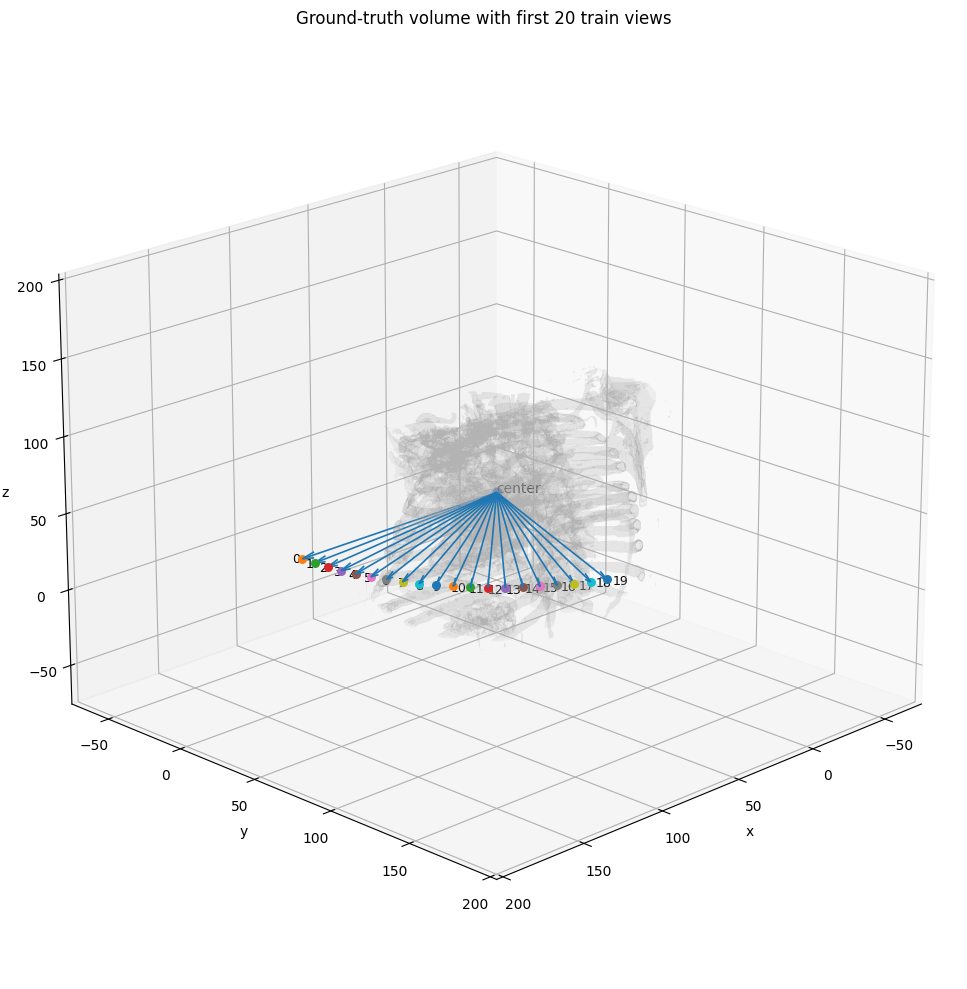

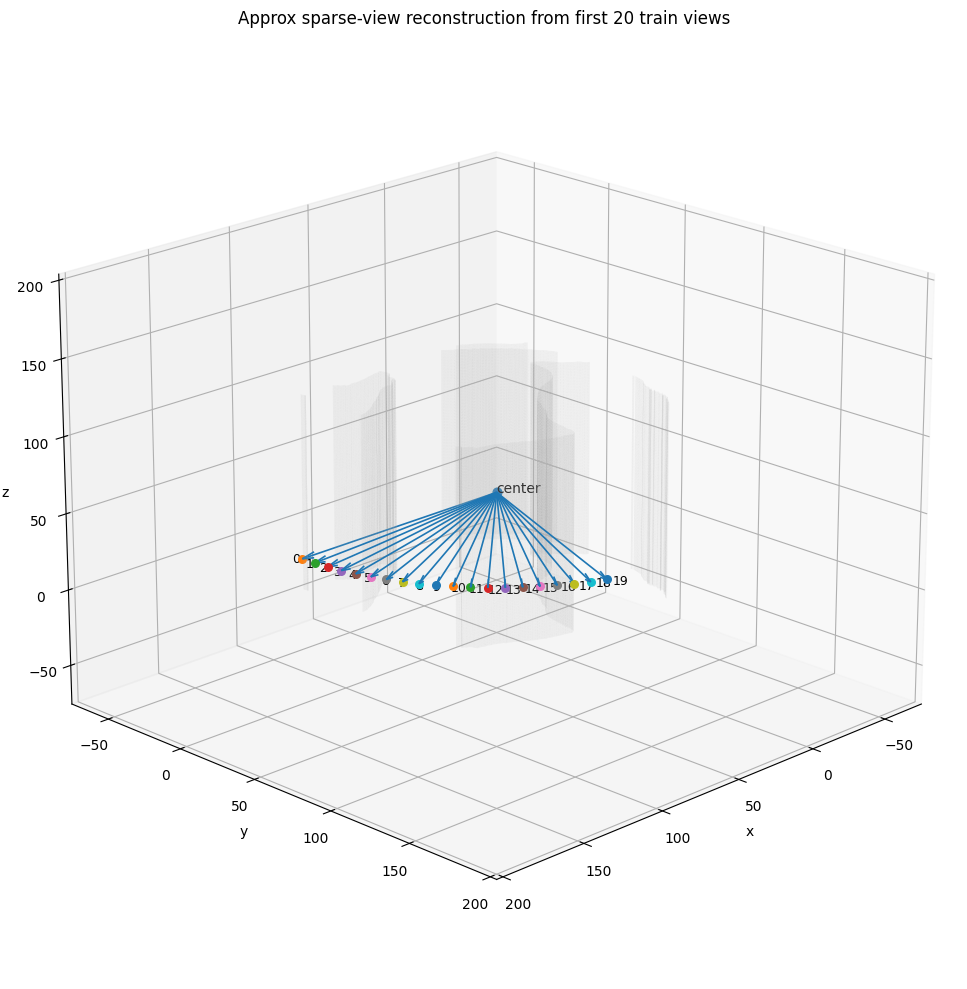

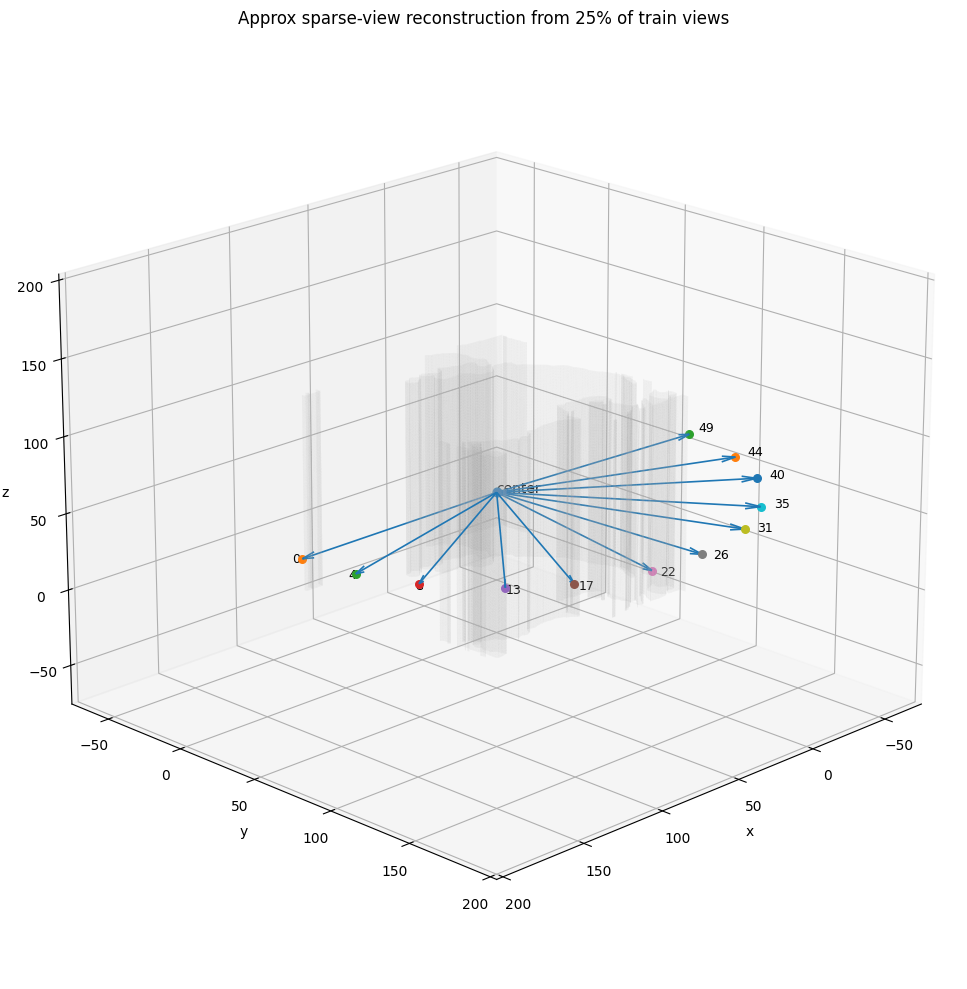

In [3]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate
from skimage import measure
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

PICKLE_PATH = "data/chest_50.pickle"

with open(PICKLE_PATH, "rb") as f:
    data = pickle.load(f)

# ---------------------------------------------------
# Ground-truth volume
# ---------------------------------------------------
true_volume = np.asarray(data["image"], dtype=np.float32)
true_volume = true_volume[::-1, ...]
true_volume = np.rot90(true_volume, -1, (0, 1))

cx = true_volume.shape[0] / 2.0
cy = true_volume.shape[1] / 2.0
cz = true_volume.shape[2] / 2.0
radius = 0.95 * max(true_volume.shape)


def get_selected_views(split_name: str, selected_indices=None, frac=None, max_views=None):
    angles_all = np.asarray(data[split_name]["angles"], dtype=float)
    projections_all = np.asarray(data[split_name]["projections"], dtype=np.float32)

    n_total = len(angles_all)

    if selected_indices is not None:
        idx = np.asarray(selected_indices, dtype=int)
    elif frac is not None:
        k = max(1, int(round(frac * n_total)))
        idx = np.linspace(0, n_total - 1, k, dtype=int)
    elif max_views is not None:
        idx = np.arange(min(max_views, n_total), dtype=int)
    else:
        idx = np.arange(n_total, dtype=int)

    return projections_all[idx], angles_all[idx], idx


def orient_projection_to_volume(proj, vol_shape):
    """
    Try to map a 2D projection to the in-plane size of the volume.
    Assumes projection corresponds roughly to (H, W) matching two volume dims.
    """
    H, W = proj.shape
    X, Y, Z = vol_shape

    # Resize by simple crop/pad if needed
    out = np.zeros((X, Y), dtype=np.float32)

    x0 = max(0, (X - H) // 2)
    y0 = max(0, (Y - W) // 2)

    hx = min(H, X)
    wy = min(W, Y)

    src_x0 = max(0, (H - X) // 2)
    src_y0 = max(0, (W - Y) // 2)

    out[x0:x0+hx, y0:y0+wy] = proj[src_x0:src_x0+hx, src_y0:src_y0+wy]
    return out


def reconstruct_sparse_volume(split_name: str, selected_indices=None, frac=None, max_views=None):
    """
    Crude approximate reconstruction from selected projections using
    simple backprojection by slab replication + rotation.
    """
    projections, angles, idx = get_selected_views(
        split_name,
        selected_indices=selected_indices,
        frac=frac,
        max_views=max_views,
    )

    X, Y, Z = true_volume.shape
    recon = np.zeros((X, Y, Z), dtype=np.float32)
    weight = np.zeros((X, Y, Z), dtype=np.float32)

    for proj, theta in zip(projections, angles):
        # Map projection into the volume x-y plane
        proj_xy = orient_projection_to_volume(proj, (X, Y, Z))

        # Replicate through depth to form a slab
        slab = np.repeat(proj_xy[:, :, None], Z, axis=2)

        # Rotate slab around volume center in x-y plane
        # scipy rotate uses degrees
        theta_deg = np.degrees(theta)
        slab_rot = rotate(
            slab,
            angle=theta_deg,
            axes=(0, 1),
            reshape=False,
            order=1,
            mode="constant",
            cval=0.0,
        )

        recon += slab_rot
        weight += (slab_rot != 0).astype(np.float32)

    recon = recon / np.maximum(weight, 1e-6)

    # Match orientation to true volume display convention if needed
    return recon, angles, idx


def make_mesh(volume, sigma=0.55):
    vmin = float(volume.min())
    vmax = float(volume.max())
    thresh = sigma * vmin + (1 - sigma) * vmax
    verts, faces, _, _ = measure.marching_cubes(volume, thresh)
    return verts, faces


def plot_volume_with_views(volume, split_name, angles, labels, title, elev=20, azim=45):
    verts, faces = make_mesh(volume)

    fig = plt.figure(figsize=(11, 10))
    ax = fig.add_subplot(111, projection="3d")

    mesh = Poly3DCollection(verts[faces], alpha=0.12)
    mesh.set_facecolor([0.7, 0.7, 0.7])
    ax.add_collection3d(mesh)

    ax.scatter([cx], [cy], [cz], s=40)
    ax.text(cx, cy, cz, "center", fontsize=10)

    for theta, label in zip(angles, labels):
        x = cx + radius * np.cos(theta)
        y = cy + radius * np.sin(theta)
        z = cz

        ax.scatter([x], [y], [z], s=30)

        dx, dy, dz = x - cx, y - cy, z - cz
        ax.quiver(
            cx, cy, cz,
            dx, dy, dz,
            arrow_length_ratio=0.06,
            linewidth=1.2,
            normalize=False
        )

        scale = 1.05
        ax.text(cx + scale * dx, cy + scale * dy, cz + scale * dz, str(label), fontsize=9)

    pad = radius * 1.15
    ax.set_xlim(cx - pad, cx + pad)
    ax.set_ylim(cy - pad, cy + pad)
    ax.set_zlim(cz - pad, cz + pad)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title(title)
    ax.view_init(elev=elev, azim=azim)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------
# Example usage
# ---------------------------------------------------

# True volume + first 20 train views
projs, angs, idx = get_selected_views("train", max_views=20)
plot_volume_with_views(
    true_volume,
    "train",
    angs,
    idx,
    title="Ground-truth volume with first 20 train views"
)

# Approx reconstructed volume from first 20 train views
recon20, angs20, idx20 = reconstruct_sparse_volume("train", max_views=20)
plot_volume_with_views(
    recon20,
    "train",
    angs20,
    idx20,
    title="Approx sparse-view reconstruction from first 20 train views"
)

# Approx reconstructed volume from 25% of train views
recon25, angs25, idx25 = reconstruct_sparse_volume("train", frac=0.25)
plot_volume_with_views(
    recon25,
    "train",
    angs25,
    idx25,
    title="Approx sparse-view reconstruction from 25% of train views"
)

/tmp/ipykernel_2478241/392667023.py:74: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(f)


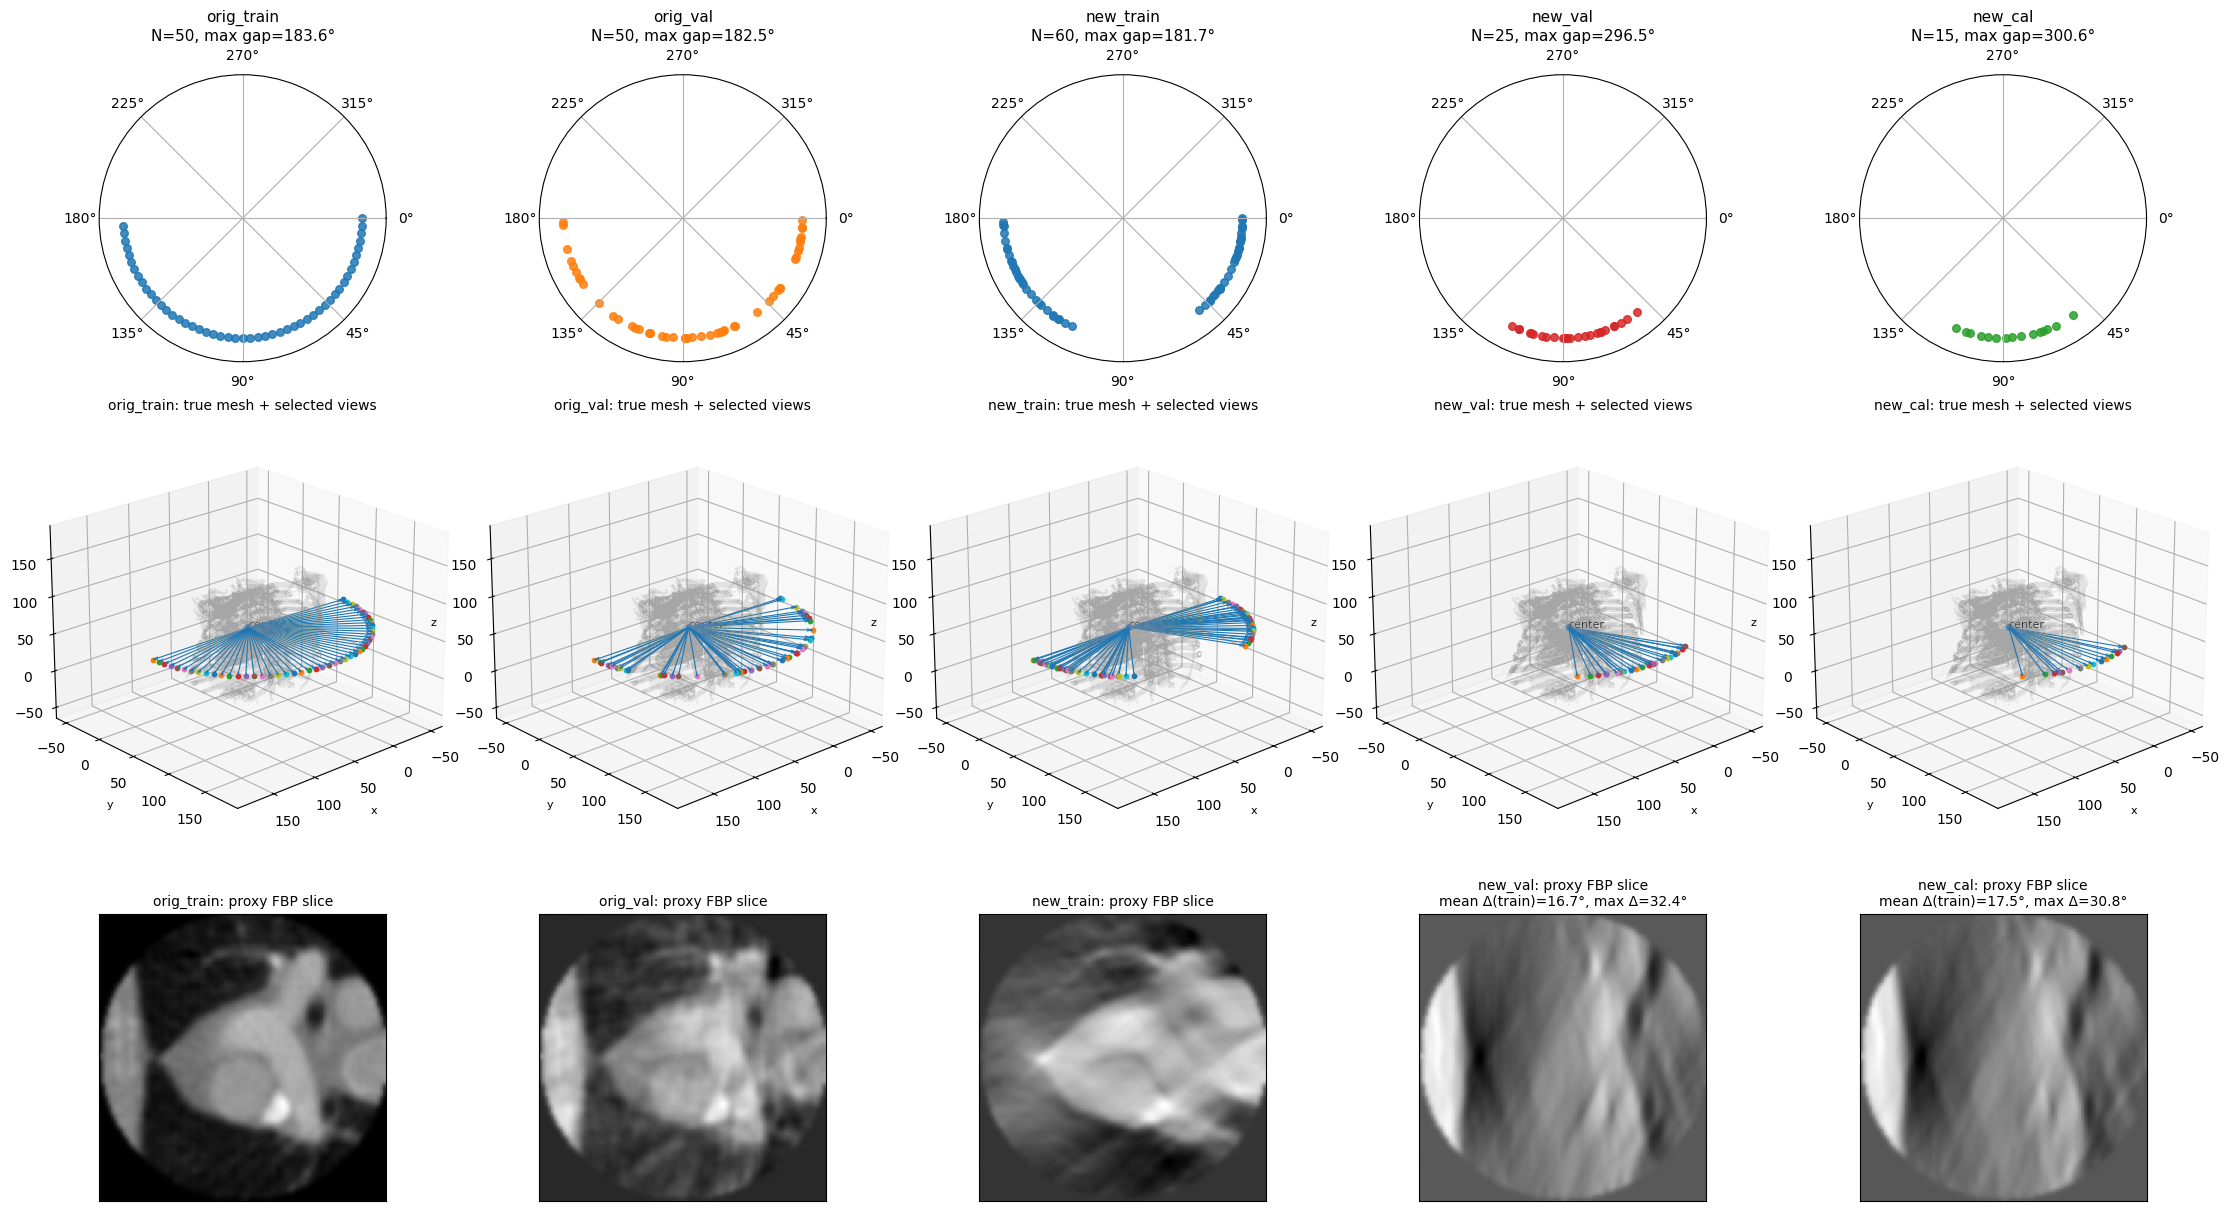


===== Original split summary =====
orig_train: N= 50, max angular gap=183.60 deg
  orig_val: N= 50, max angular gap=182.46 deg

===== Proposed split summary =====
Observed angle range: [0.00°, 178.25°]
Held-out middle 40% angle range: [51.68°, 115.20°]
 new_train: N= 60, max angular gap=181.75 deg
   new_val: N= 25, max angular gap=296.48 deg, mean nearest-train gap=16.74 deg, max nearest-train gap=32.40 deg
   new_cal: N= 15, max angular gap=300.63 deg, mean nearest-train gap=17.46 deg, max nearest-train gap=30.85 deg


In [7]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from scipy.ndimage import gaussian_filter
from skimage import measure
from skimage.transform import iradon
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


# ============================================================
# Config
# ============================================================
PICKLE_PATH = "data/chest_50.pickle"

# Fractions over the COMBINED original train+val pool
TRAIN_FRAC = 0.60
VAL_FRAC = 0.25
CAL_FRAC = 0.15

# Reconstruction proxy settings
RECON_NXY = 96
RECON_NZ = 72
GAUSSIAN_SIGMA = 0.8
MC_SIGMA = 0.55
MAX_ARROWS = 60

# Figure settings
FIGSIZE = (22, 12)
ELEV = 22
AZIM = 48


# ============================================================
# Helpers
# ============================================================
def wrap_angle_0_2pi(theta):
    return np.mod(theta, 2 * np.pi)


def smallest_angle_diff(a, b):
    d = np.abs(a - b)
    return np.minimum(d, 2 * np.pi - d)


@dataclass
class SplitViews:
    name: str
    indices: np.ndarray
    angles: np.ndarray
    projections: np.ndarray


def summarize_split_vs_train(split_angles, train_angles):
    if len(split_angles) == 0:
        return {"mean_nearest_train_deg": np.nan, "max_nearest_train_deg": np.nan}

    dists = []
    for th in split_angles:
        d = np.min(smallest_angle_diff(th, train_angles))
        dists.append(np.rad2deg(d))
    dists = np.asarray(dists)
    return {
        "mean_nearest_train_deg": float(dists.mean()),
        "max_nearest_train_deg": float(dists.max()),
    }


# ============================================================
# Data loading
# ============================================================
with open(PICKLE_PATH, "rb") as f:
    data = pickle.load(f)

true_volume = np.asarray(data["image"], dtype=np.float32)
true_volume = true_volume[::-1, ...]
true_volume = np.rot90(true_volume, -1, axes=(0, 1))

orig_train_angles = np.asarray(data["train"]["angles"], dtype=np.float32)
orig_train_projs = np.asarray(data["train"]["projections"], dtype=np.float32)

orig_val_angles = np.asarray(data["val"]["angles"], dtype=np.float32)
orig_val_projs = np.asarray(data["val"]["projections"], dtype=np.float32)

all_angles = np.concatenate([orig_train_angles, orig_val_angles], axis=0)
all_projs = np.concatenate([orig_train_projs, orig_val_projs], axis=0)

n_total = len(all_angles)
assert np.isclose(TRAIN_FRAC + VAL_FRAC + CAL_FRAC, 1.0), "Fractions must sum to 1."


# ============================================================
# Proposed middle-held-out angular reassignment
# ============================================================
def make_middle_holdout_split(
    all_angles,
    all_projs,
    train_frac=0.60,
    val_frac=0.25,
    cal_frac=0.15,
):
    """
    Sort views by angle over the observed acquisition range and carve out the
    middle contiguous 40% block as held-out views.

    The held-out middle block is then split uniformly into:
      - validation: 25% of all views
      - calibration: 15% of all views

    The outer 60% (left + right angular sectors) becomes training.
    """
    all_angles = np.asarray(all_angles)
    all_projs = np.asarray(all_projs)

    order = np.argsort(all_angles)
    sorted_angles = all_angles[order]

    n = len(order)
    n_train = int(round(train_frac * n))
    n_val = int(round(val_frac * n))
    n_cal = n - n_train - n_val
    n_holdout = n_val + n_cal

    # Middle contiguous 40% block
    holdout_start = (n - n_holdout) // 2
    holdout_end = holdout_start + n_holdout

    left_train_idx = order[:holdout_start]
    middle_holdout_idx = order[holdout_start:holdout_end]
    right_train_idx = order[holdout_end:]

    # Uniform split of the middle block into val and cal
    n_middle = len(middle_holdout_idx)
    n_val_middle = int(round((val_frac / (val_frac + cal_frac)) * n_middle))
    n_cal_middle = n_middle - n_val_middle


    middle_idx = np.asarray(middle_holdout_idx)

    if n_val_middle > 0:
        val_positions = np.linspace(0, len(middle_idx) - 1, n_val_middle)
        val_positions = np.round(val_positions).astype(int)
        val_positions = np.unique(val_positions)

        # If rounding caused too few unique positions, fill from unused positions
        if len(val_positions) < n_val_middle:
            used = set(val_positions.tolist())
            extras = [i for i in range(len(middle_idx)) if i not in used]
            need = n_val_middle - len(val_positions)
            val_positions = np.sort(np.concatenate([val_positions, extras[:need]]))

        # If rounding caused too many, trim
        if len(val_positions) > n_val_middle:
            val_positions = val_positions[:n_val_middle]
    else:
        val_positions = np.array([], dtype=int)

    val_mask = np.zeros(len(middle_idx), dtype=bool)
    val_mask[val_positions] = True

    val_idx = middle_idx[val_mask]
    cal_idx = middle_idx[~val_mask]
    train_idx = np.concatenate([left_train_idx, right_train_idx], axis=0)

    # val_idx = middle_holdout_idx[:n_val_middle]
    # cal_idx = middle_holdout_idx[n_val_middle:n_val_middle + n_cal_middle]
    # train_idx = np.concatenate([left_train_idx, right_train_idx], axis=0)

    splits = {
        "new_train": SplitViews(
            "new_train",
            np.asarray(train_idx),
            all_angles[train_idx],
            all_projs[train_idx],
        ),
        "new_val": SplitViews(
            "new_val",
            np.asarray(val_idx),
            all_angles[val_idx],
            all_projs[val_idx],
        ),
        "new_cal": SplitViews(
            "new_cal",
            np.asarray(cal_idx),
            all_angles[cal_idx],
            all_projs[cal_idx],
        ),
    }

    meta = {
        "sorted_angles": sorted_angles,
        "holdout_start": holdout_start,
        "holdout_end": holdout_end,
        "n_total": n,
        "n_train": len(train_idx),
        "n_val": len(val_idx),
        "n_cal": len(cal_idx),
        "angle_min_deg": float(np.rad2deg(sorted_angles.min())),
        "angle_max_deg": float(np.rad2deg(sorted_angles.max())),
        "holdout_min_deg": float(np.rad2deg(sorted_angles[holdout_start])),
        "holdout_max_deg": float(np.rad2deg(sorted_angles[holdout_end - 1])),
    }

    return splits, meta


proposed, split_meta = make_middle_holdout_split(
    all_angles,
    all_projs,
    train_frac=TRAIN_FRAC,
    val_frac=VAL_FRAC,
    cal_frac=CAL_FRAC,
)

original_splits = {
    "orig_train": SplitViews("orig_train", np.arange(len(orig_train_angles)), orig_train_angles, orig_train_projs),
    "orig_val": SplitViews("orig_val", np.arange(len(orig_val_angles)), orig_val_angles, orig_val_projs),
}

all_display_splits = {
    "orig_train": original_splits["orig_train"],
    "orig_val": original_splits["orig_val"],
    "new_train": proposed["new_train"],
    "new_val": proposed["new_val"],
    "new_cal": proposed["new_cal"],
}


# ============================================================
# Proxy reconstruction: slice-wise FBP
# ============================================================
def reconstruct_proxy_volume_from_views(
    projections,
    angles,
    out_xy=96,
    out_z=72,
    smooth_sigma=0.8,
):
    projections = np.asarray(projections, dtype=np.float32)
    angles = np.asarray(angles, dtype=np.float32)

    if len(angles) < 2:
        return np.zeros((out_xy, out_xy, out_z), dtype=np.float32)

    order = np.argsort(wrap_angle_0_2pi(angles))
    angles = wrap_angle_0_2pi(angles[order])
    projections = projections[order]

    n_views, det_h, det_w = projections.shape
    z_rows = np.linspace(0, det_h - 1, out_z).astype(int)
    theta_deg = np.mod(np.rad2deg(angles), 180.0)

    recon_slices = []
    for row in z_rows:
        sino = projections[:, row, :].T

        sino = sino - np.min(sino)
        if np.max(sino) > 0:
            sino = sino / np.max(sino)

        try:
            rec = iradon(
                sino,
                theta=theta_deg,
                output_size=out_xy,
                filter_name="ramp",
                circle=True,
            )
        except Exception:
            rec = np.zeros((out_xy, out_xy), dtype=np.float32)

        recon_slices.append(rec.astype(np.float32))

    vol = np.stack(recon_slices, axis=-1)

    vol = vol - vol.min()
    if vol.max() > 0:
        vol = vol / vol.max()

    if smooth_sigma and smooth_sigma > 0:
        vol = gaussian_filter(vol, sigma=smooth_sigma)

    return vol.astype(np.float32)


# ============================================================
# Mesh helpers
# ============================================================
def make_mesh(volume, sigma=0.55):
    vmin = float(volume.min())
    vmax = float(volume.max())
    if vmax <= vmin:
        return None, None

    thresh = sigma * vmin + (1.0 - sigma) * vmax

    try:
        verts, faces, _, _ = measure.marching_cubes(volume, thresh)
        return verts, faces
    except Exception:
        return None, None


true_verts, true_faces = make_mesh(true_volume, sigma=MC_SIGMA)

proxy_volumes = {}
proxy_center_slices = {}

for name, split in all_display_splits.items():
    vol = reconstruct_proxy_volume_from_views(
        split.projections,
        split.angles,
        out_xy=RECON_NXY,
        out_z=RECON_NZ,
        smooth_sigma=GAUSSIAN_SIGMA,
    )
    proxy_volumes[name] = vol
    proxy_center_slices[name] = vol[:, :, vol.shape[2] // 2]


# ============================================================
# Plotting
# ============================================================
def plot_polar_coverage(ax, split: SplitViews, color="C0"):
    angles = wrap_angle_0_2pi(split.angles)
    radii = np.ones_like(angles)

    ax.scatter(angles, radii, s=30, alpha=0.85, color=color)
    ax.set_yticks([])
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(-1)
    ax.set_ylim(0, 1.2)

    a = np.sort(angles)
    if len(a) >= 2:
        diffs = np.diff(np.r_[a, a[0] + 2 * np.pi])
        max_gap = np.rad2deg(diffs.max())
    else:
        max_gap = np.nan

    ax.set_title(f"{split.name}\nN={len(angles)}, max gap={max_gap:.1f}°", fontsize=11)


def plot_true_mesh_with_views(ax, split: SplitViews):
    if true_verts is not None and true_faces is not None:
        mesh = Poly3DCollection(true_verts[true_faces], alpha=0.10)
        mesh.set_facecolor([0.65, 0.65, 0.65])
        mesh.set_edgecolor("none")
        ax.add_collection3d(mesh)

    X, Y, Z = true_volume.shape
    cx, cy, cz = X / 2.0, Y / 2.0, Z / 2.0
    radius = 0.90 * max(true_volume.shape)

    ax.scatter([cx], [cy], [cz], s=18)
    ax.text(cx, cy, cz, "center", fontsize=8)

    angles = split.angles
    if len(angles) > MAX_ARROWS:
        idx = np.linspace(0, len(angles) - 1, MAX_ARROWS).astype(int)
        angles = angles[idx]

    for theta in angles:
        x = cx + radius * np.cos(theta)
        y = cy + radius * np.sin(theta)
        z = cz

        dx, dy, dz = x - cx, y - cy, z - cz

        ax.scatter([x], [y], [z], s=10)
        ax.quiver(
            cx, cy, cz,
            dx, dy, dz,
            arrow_length_ratio=0.05,
            linewidth=0.8,
            normalize=False
        )

    pad = radius * 1.12
    ax.set_xlim(cx - pad, cx + pad)
    ax.set_ylim(cy - pad, cy + pad)
    ax.set_zlim(cz - pad, cz + pad)

    ax.set_xlabel("x", fontsize=8)
    ax.set_ylabel("y", fontsize=8)
    ax.set_zlabel("z", fontsize=8)
    ax.view_init(elev=ELEV, azim=AZIM)
    ax.set_title(f"{split.name}: true mesh + selected views", fontsize=10)


def plot_proxy_slice(ax, split_name, split: SplitViews, new_train_angles=None):
    sl = proxy_center_slices[split_name]
    ax.imshow(sl.T, cmap="gray", origin="lower")
    ax.set_xticks([])
    ax.set_yticks([])

    title = f"{split.name}: proxy FBP slice"

    if split_name in ["new_val", "new_cal"] and new_train_angles is not None:
        stats = summarize_split_vs_train(split.angles, new_train_angles)
        title += (
            f"\nmean Δ(train)={stats['mean_nearest_train_deg']:.1f}°"
            f", max Δ={stats['max_nearest_train_deg']:.1f}°"
        )

    ax.set_title(title, fontsize=10)


# ============================================================
# Make figure
# ============================================================
names = ["orig_train", "orig_val", "new_train", "new_val", "new_cal"]
colors = {
    "orig_train": "C0",
    "orig_val": "C1",
    "new_train": "C0",
    "new_val": "C3",
    "new_cal": "C2",
}

fig = plt.figure(figsize=FIGSIZE, constrained_layout=True)
gs = fig.add_gridspec(3, len(names), height_ratios=[1.0, 1.65, 1.0])

for col, name in enumerate(names):
    split = all_display_splits[name]

    ax1 = fig.add_subplot(gs[0, col], projection="polar")
    plot_polar_coverage(ax1, split, color=colors[name])

    ax2 = fig.add_subplot(gs[1, col], projection="3d")
    plot_true_mesh_with_views(ax2, split)

    ax3 = fig.add_subplot(gs[2, col])
    plot_proxy_slice(ax3, name, split, new_train_angles=proposed["new_train"].angles)

plt.show()


# ============================================================
# Optional: print summary + save new split
# ============================================================
def print_split_summary():
    print("\n===== Original split summary =====")
    for name in ["orig_train", "orig_val"]:
        s = all_display_splits[name]
        a = np.sort(wrap_angle_0_2pi(s.angles))
        diffs = np.diff(np.r_[a, a[0] + 2*np.pi]) if len(a) > 1 else np.array([np.nan])
        print(
            f"{name:>10s}: N={len(s.angles):3d}, "
            f"max angular gap={np.rad2deg(np.nanmax(diffs)):.2f} deg"
        )

    print("\n===== Proposed split summary =====")
    print(
        f"Observed angle range: "
        f"[{split_meta['angle_min_deg']:.2f}°, {split_meta['angle_max_deg']:.2f}°]"
    )
    print(
        f"Held-out middle 40% angle range: "
        f"[{split_meta['holdout_min_deg']:.2f}°, {split_meta['holdout_max_deg']:.2f}°]"
    )

    train_angles = proposed["new_train"].angles
    for name in ["new_train", "new_val", "new_cal"]:
        s = proposed[name]
        a = np.sort(wrap_angle_0_2pi(s.angles))
        diffs = np.diff(np.r_[a, a[0] + 2*np.pi]) if len(a) > 1 else np.array([np.nan])
        msg = (
            f"{name:>10s}: N={len(s.angles):3d}, "
            f"max angular gap={np.rad2deg(np.nanmax(diffs)):.2f} deg"
        )
        if name != "new_train":
            stats = summarize_split_vs_train(s.angles, train_angles)
            msg += (
                f", mean nearest-train gap={stats['mean_nearest_train_deg']:.2f} deg"
                f", max nearest-train gap={stats['max_nearest_train_deg']:.2f} deg"
            )
        print(msg)


print_split_summary()


def save_reassigned_pickle(out_path):
    new_data = dict(data)

    new_data["train"] = {
        "angles": proposed["new_train"].angles,
        "projections": proposed["new_train"].projections,
    }
    new_data["val"] = {
        "angles": proposed["new_val"].angles,
        "projections": proposed["new_val"].projections,
    }
    new_data["cal"] = {
        "angles": proposed["new_cal"].angles,
        "projections": proposed["new_cal"].projections,
    }

    new_data["numTrain"] = len(proposed["new_train"].angles)
    new_data["numVal"] = len(proposed["new_val"].angles)
    new_data["numCal"] = len(proposed["new_cal"].angles)

    with open(out_path, "wb") as f:
        pickle.dump(new_data, f)

    print(f"\nSaved reassigned pickle to: {out_path}")


# Uncomment if desired:
# save_reassigned_pickle("data/chest_50_reassigned_train_val_cal.pickle")

In [8]:
save_reassigned_pickle("data/chest_50_reassigned_train_val_cal.pickle")


Saved reassigned pickle to: data/chest_50_reassigned_train_val_cal.pickle
